- Παληκαρίδης Τηλέμαχος , TH20013

Τελικό Project Εργαστηρίου Patter_Recognition

# Project 

- Β. IMPLEMENTATION

Αρχικά θα χρειαστούμε να δηλώσουμε κάποια αντίστοιχα imports στα οποία θα χρειαστούμε για την επίλυση της άσκησης του τελικού Project συνολικά θα χρειαστούμε imports στα οποία θα απαντήσουμε σε όλα τα ερωτήματα του Project και όπου χρειάζονται 

- STEP 1 – Data Selection

In [86]:
#Along with this document you will also find two datasets.
#➢ A description of each dataset exists in the respective .names file (open it with a text editor).
#➢ Choose one of the two datasets.
#➢ Import the chosen dataset in Jupyter notebook.

In [100]:
#Δηλώνουμε τις αντίστοιχες μεταβλητές Imports 
#import 
import numpy as np 
import pandas as pd 
from numpy import std 
import matplotlib.pyplot as plt 
#sklearn
from sklearn import preprocessing 
from sklearn import datasets 
from sklearn.cluster import KMeans
from sklearn import svm 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.datasets import make_blobs
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
#scipy
import scipy.cluster.hierarchy as shc 
from scipy.cluster.hierarchy import inconsistent, fcluster ,ward, single
from scipy.spatial.distance import squareform, pdist 
#imports for kmeans
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
import scipy.spatial.distance as ssd
from scipy.spatial.distance import squareform, pdist
from scipy.cluster.hierarchy import ward, dendrogram, linkage
from scipy.cluster.hierarchy import dendrogram, linkage
%matplotlib inline 

In [101]:
#Στην συνέχεια θα χρειαστούμε να διαλέξουμε μεταξύ των 2 αρχείων που υπάρχουν στο 
#zip αρχείο όπου βρίσκονται με ονόματα #Breast-Cancer / #Ionosphere
#Επιλέγω το αρχείο όπου θα δουλέψω το τελικ΄ο Project το #Ionosphere
#Στην συνέχεια θα ξεκινήσει η διαδικασία της άσκησης αφότου έχουμε δηλ΄ώσει
#τα αντίστοιχα imports 

In [102]:
#Ορίζουμε το αρχείο .data του οποίου κατεβάσαμε με όνομα #Ionosphre 
#Εδώ ορίζουμε το Ionosphere.data με όνομα ionosphere_file ώστε να δεχτεί την νέα του ονομασία 
ionosphere_file="ionosphere.data"
#Τι δηλώνουμε σαν μεταβλητή df και ζητάμε να εκτυπωθε΄ί με τον πίνακα 
df = pd.read_csv('ionosphere.data')
#θα εκτυπωθεί ο πίνακας #Ionosphere
df 

,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.1,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
0,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
1,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
2,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
3,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g
4,1,0,0.02337,-0.00592,-0.09924,-0.11949,-0.00763,-0.11824,0.14706,0.06637,...,-0.01535,-0.03240,0.09223,-0.07859,0.00732,0.00000,0.00000,-0.00039,0.12011,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,1,0,0.83508,0.08298,0.73739,-0.14706,0.84349,-0.05567,0.90441,-0.04622,...,-0.04202,0.83479,0.00123,1.00000,0.12815,0.86660,-0.10714,0.90546,-0.04307,g
346,1,0,0.95113,0.00419,0.95183,-0.02723,0.93438,-0.01920,0.94590,0.01606,...,0.01361,0.93522,0.04925,0.93159,0.08168,0.94066,-0.00035,0.91483,0.04712,g
347,1,0,0.94701,-0.00034,0.93207,-0.03227,0.95177,-0.03431,0.95584,0.02446,...,0.03193,0.92489,0.02542,0.92120,0.02242,0.92459,0.00442,0.92697,-0.00577,g
348,1,0,0.90608,-0.01657,0.98122,-0.01989,0.95691,-0.03646,0.85746,0.00110,...,-0.02099,0.89147,-0.07760,0.82983,-0.17238,0.96022,-0.03757,0.87403,-0.16243,g


Παρατηρούμε τον αντίστοιχο πίνακα που αποτυπώνεται με όλες τις τιμές του με βάση τα δεδομένα που μας δώθηκαν από το αρχείο ionosphere.data περιέχονται περίπου 349 τιμές αντίστοιχα στις οποίες δηλώσαμε να διαβάζει το αρχέιο και αφότου θα εκτυπωθεί με νέο όρισμα ονομασίας .

In [103]:
#Στην συνέχεια δηλώνουμε τα Labels που θα εφάρμόσουμε στα δεδομενα
#του ίδιου πίνακα μόνο που θα ΄ορίζουμε τα δεδομένα με τa αντίστοιχα labels
#όπως αποτιπώνεται παρακάτω 
label =['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z','A1','B1','C1','D1','E1','F1','G1','H1','I1']
#ορίζουμε τις ετικέτες labels με νέο όνομα ώστε να εκτυπωθούν ώστε να πάρουν μια νέα
#μεταβλετή 
df.columns= label
#Ζητάμε να εκτυπωθεί ο νέος πινακας με τα labels όπου θα είναι ίδιος με τον αρχικό 
df

,A,B,C,D,E,F,G,H,I,J,...,Z,A1,B1,C1,D1,E1,F1,G1,H1,I1
0,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
1,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
2,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
3,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g
4,1,0,0.02337,-0.00592,-0.09924,-0.11949,-0.00763,-0.11824,0.14706,0.06637,...,-0.01535,-0.03240,0.09223,-0.07859,0.00732,0.00000,0.00000,-0.00039,0.12011,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,1,0,0.83508,0.08298,0.73739,-0.14706,0.84349,-0.05567,0.90441,-0.04622,...,-0.04202,0.83479,0.00123,1.00000,0.12815,0.86660,-0.10714,0.90546,-0.04307,g
346,1,0,0.95113,0.00419,0.95183,-0.02723,0.93438,-0.01920,0.94590,0.01606,...,0.01361,0.93522,0.04925,0.93159,0.08168,0.94066,-0.00035,0.91483,0.04712,g
347,1,0,0.94701,-0.00034,0.93207,-0.03227,0.95177,-0.03431,0.95584,0.02446,...,0.03193,0.92489,0.02542,0.92120,0.02242,0.92459,0.00442,0.92697,-0.00577,g
348,1,0,0.90608,-0.01657,0.98122,-0.01989,0.95691,-0.03646,0.85746,0.00110,...,-0.02099,0.89147,-0.07760,0.82983,-0.17238,0.96022,-0.03757,0.87403,-0.16243,g


Παρατηρούμε ότι εκτυπώνεται ένας πίνακας δεδομένων με τις αντίστοιχες τιμές που ύπαρχουν μέσα στο αρχείο ionosphere.data με τα δεδομένα που δίνονται στ  στο αρχείου ionosphere.names και έχουμε τον αντίστοιχο πίνακα που αποικονίζεται ολοκληρωμένος ακριβώς από πάνω με labels προτίμησεις .

- STEP 2 – Data inspection

In [104]:
#➢ Check data for missing values and replace them (if any).
#➢ If the class (category) of each pattern is embedded in the data, create a separate table that stores these values.
#➢ Check your data columns (features). If some of them contain unnecessary information about the 
#classifier, remove them. The .names file may provide you important information regarding this point

Δεν υπάρχουν τιμές που λείπουν για τα δεδομένα ,Έτσι ώστε δεν χρειάζεται να δημιουργήσουμε έναν ξεχωριστό πίνακα με τις αντίστοιχες τιμές 
Έχει γίνει ο αντίστοιχος ελέγχος για  τις στήλες των δεδομένων και από το αρχείο .names δεν υπάρχουν περιττά δεδομένα οπότε δεν χρειάζεται η δημιουργεία και να χρήση κάποιου διαφορετικού δεδομένου.

- STEP 3 – Data Prepossessing 

In [105]:
#➢ Use boxplots and descriptive statistics to derive -and report- your conclusions about the dataset you have chosen.
#➢ Remove outliers (if any).
#➢ Transform your data into [0 - 1] or in such a way that it has a mean value of 0 and a standard  deviation of 1.
#➢ Use scatter plots to show your data. What do you conclude?
#➢ Find and keep the best features.
#➢ Divide your data into a training (70%) and a test set (30%)

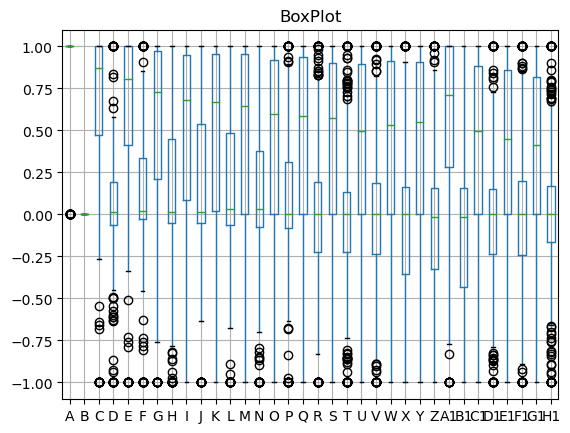

In [106]:
#Με την χρήση του boxplots όπως χρησιμοποιήθηκε παρακάτω αποτυπώνεται το αντίστοιχο γράφημα 
label=['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z','A1','B1','C1','D1','E1','F1','G1','H1']
#Γίνεται η δημιουργεία μεταβλητών Data , Targets
X = df.loc[:,label]
Y=df['I1']
fig,ax=plt.subplots()
#Ορίζουμε τίτλο με όνομα BoxPlot 
ax.set_title('BoxPlot')
#Ζητάμε να εκτυπωθεί ο πίνακας του df με τα νεά ορίσματα και με βάση τον πίνακα
df.boxplot();

Παρατηρούμε στο αντίστοιχο γράφημα του BoxPlot ότι τα ορίσματα για την μέγιστη και την ελάχιστη τιμή αποτυπώνονται παραπάνω. Υπάρχουν αλλές 3 διακρίσεις ευθειών οι οποίες είναι το πρώτο τεταρτιμόριο το τρίτο τεταρτιμόριο και η διάμεσος με βάση το γράφημα (όπως αναγράφει και η θεωρία) ,ανάλογα με τα αντίστοιχα A-H1 Παρατηρούμε διαφορετικές τιμές που παίρνουν οι διάμεσοι καθώς προχωράνε οι τιμές στον πίνακα. Άλλες τιμές πλησιάζουν την μέγιστη τιμή άλλες είναι στο μισό τις αντίστοιχης τιμής με βάση την αποικόνιση του πίνακα.

In [107]:
#Τ΄ώρα θα κάνουμε Transform data to [0-1]
#Ορίζουμε την αντίστοιχη κανονικοποίηση του min_max_scaler
#Κάνουμε Divide your data into a training (70%) and a test set (30%)
#Κάνουμε χρήση του minmax_scaler 
min_max_scaler = preprocessing.MinMaxScaler()
#Το ορίζουμε ως μια μεταβλητή x_minmax και στην συνέχεια ζητ΄άμε να εκτυπωθεί ο αντίστοιχος κανονικοποιημένος πίνακας 
x_minmax = min_max_scaler.fit_transform(X)

In [108]:
#Θα εκτυπωθεί ο κανονικοποιημένος πίνακας 
x_minmax

array([[1.    , 0.    , 1.    , ..., 0.4686, 0.4313, 0.4878],
       [1.    , 0.    , 1.    , ..., 0.3791, 0.7802, 0.3088],
       [1.    , 0.    , 1.    , ..., 1.    , 0.3381, 1.    ],
       ...,
       [1.    , 0.    , 0.9735, ..., 0.5022, 0.9635, 0.4971],
       [1.    , 0.    , 0.953 , ..., 0.4812, 0.937 , 0.4188],
       [1.    , 0.    , 0.9235, ..., 0.4666, 0.9288, 0.4692]])

In [109]:
#ορίζουμε τις μεταβλητές X_train, Y_train, X_test, Y_test
#Δήνωντας τις τιμές για test_size=0.3
X_train= train_test_split(X,Y,test_size=0.3)
X_test= train_test_split(X,Y,test_size=0.3)
Y_train= train_test_split(X,Y,test_size=0.3)
Y_test = train_test_split(X,Y,test_size=0.3)

#αλλάζοντας το test_size έχουμε τις ίδιες μεταβλη΄τές αλλάζοντας μονο τοy test_size=0.4
X_train= train_test_split(X,Y,test_size=0.4)
X_test= train_test_split(X,Y,test_size=0.4)
Y_train= train_test_split(X,Y,test_size=0.4)
Y_test = train_test_split(X,Y,test_size=0.4)

#Και για τιμές του test_size=0.1
X_train= train_test_split(X,Y,test_size=0.1)
X_test= train_test_split(X,Y,test_size=0.1)
Y_train= train_test_split(X,Y ,test_size=0.1)
Y_test = train_test_split(X,Y,test_size=0.1)

C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical left == right == 0.0 results in singular transformations; automatically expanding.
  ax.set_xlim(boundaries_list[j])
C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\pandas\plotting\_matplotlib\misc.py:102: UserWarning: Attempting to set identical bottom == top == 0.0 results in singular transformations; automatically expanding.
  ax.set_ylim(boundaries_list[i])
C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\pandas\plotting\_matplotlib\misc.py:92: UserWarning: Attempting to set identical left == right == 0.0 results in singular transformations; automatically expanding.
  ax.set_xlim(boundaries_list[i])


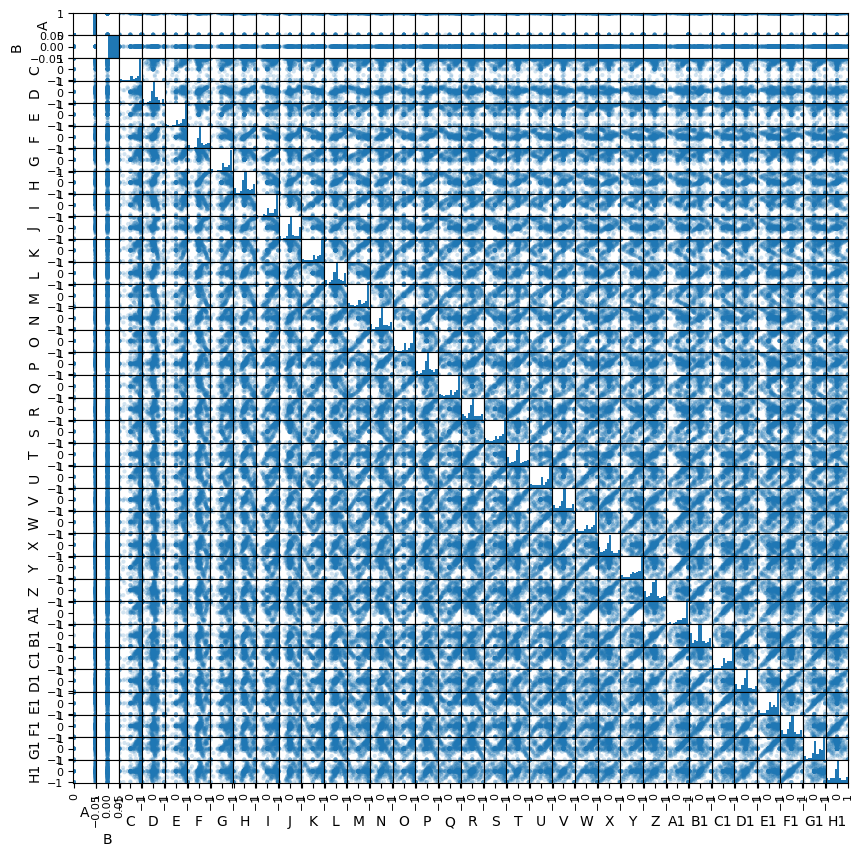

In [110]:
pd.plotting.scatter_matrix(X, alpha=0.2, figsize=(10, 10))
plt.show()

In [111]:
#Θέλουμε να βρούμε τις ακριβ΄ές τιμές του κανονικοποιημένου πίνακα που έχουμε ορίσει 
#X_train, Y_train, Y_test, X_train αντίστοιχα 
clf = svm.SVC(kernel='linear', C=1)
scores = cross_val_score(clf, X,Y, cv=5)
#Ζητάμε να εκτυπώσει τις τιμές του αντίστοιχου πίνακα που το έχουμε ορίσει scores
scores

array([0.8   , 0.8143, 0.8286, 0.9429, 0.9   ])

Παρατηρούμε τις αντίστοιχες τιμές μια σειρά από βαθμολοδίες που επιστρέφει ο εκτιμητής για καθε εκτέλεση της εντολής score.

- STEP 4 – Supervised learning (Classification)

In [112]:
#➢ Implement a linear and a quadratic classifier.
#➢ Present to the trained classifiers the test set.
#➢ Use the classification error -and other evaluation metrics- to evaluate each classifier.
#➢ Try multiple ways of separating data e.g., 80% -20%, 90% -10% and compare the performance of each classifier
#➢ What are your conclusions?

In [113]:
#Implement a linear and a quadratic classifier.
#Στην συνέχεια θα δηλώσουμε η εκτέλεση για το LinearDiscriminantAnalysis θα έχουμε ότι 
clf = LinearDiscriminantAnalysis()
#Ορίζουμε τις τιμές που θα χρησιμοποιηθο΄΄υν με το LinearDiscriminantAnalysis
clf.fit(X,Y)
#Εκτυπώνει την τιμή LinearDiscriminantAnalysis 
clf.score(X,Y)

0.9028571428571428

In [114]:
#Implement a linear and a quadratic classifier.
#Στην συνέχεια θα δηλώσουμε η εκτέλεση για το QuadraticDiscriminantAnalysis θα έχουμε ότι 
clf = QuadraticDiscriminantAnalysis()
#Ορίζουμε τις τιμές που θα χρησιμοποιηθο΄΄υν με το QuadraticDiscriminantAnalysis
clf.fit(X,Y)
#Εκτυπώνει την τιμή QuadraticDiscriminantAnalysis
clf.score(X,Y)

C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\discriminant_analysis.py:887: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


0.9542857142857143

In [115]:
#Ορίζουμε για τις τιμές που θα έχει το y_pred που θα εκτυπώσουν από τον κανονικοποιημενο πίνακα
#για τις τιμές του κανονικοποιημένου πίνακα x_minmax
y_pred1=clf.predict(x_minmax)
y_pred1

C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


array(['g', 'g', 'b', 'g', 'g', 'g', 'b', 'g', 'g', 'g', 'g', 'g', 'g',
       'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'g', 'g',
       'b', 'g', 'b', 'g', 'b', 'g', 'g', 'g', 'g', 'g', 'b', 'g', 'g',
       'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g',
       'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'g',
       'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g',
       'b', 'g', 'b', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'b',
       'g', 'b', 'g', 'b', 'g', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b',
       'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'g', 'g',
       'b', 'g', 'g', 'g', 'b', 'g', 'b', 'g', 'g', 'g', 'b', 'g', 'b',
       'g', 'b', 'g', 'b', 'g', 'b', 'g', 'g', 'g', 'b', 'g', 'g', 'g',
       'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g',
       'g', 'g', 'g', 'g', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g',
       'b', 'g', 'b', 'g', 'b', 'g', 'b', 'g', 'g', 'g', 'b', 'g

- STEP 5 – Unsupervised learning (k-means)

In [116]:
#➢ Find the optimal value of k by deploying the Elbow method and Silhouette Analysis. 
#➢ Deploy the k-means algorithm to your data. 

In [118]:
#Χρησιμοποιούμε μια for για την loop ώστε να αλλάζει ο αριθμός με τον χρόνο 
#έτσι θα πάρουμε ποίο δυνατά αποτελέσματα 
distortions = []
for i in range(1, 11):
 km = KMeans(
 n_clusters=i, init='random',
 n_init=10, max_iter=300,
 tol=1e-04, random_state=0
 )
 km.fit(x_minmax)
 distortions.append(km.inertia_)

C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmea

In [120]:
#Ορίζουμε τα αντίστοιχα για Kmeans που θα χρειαστούμε 
X = df.loc[:,label].values
Y = df['I1'].values
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
kmeans.fit(X)

C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=3)

In [121]:
#Ορίζουμε το Kmeans με τις τιμές του κανονικοποιημένου πίνακα 
kmeans = KMeans(n_clusters=3, random_state=0).fit(x_minmax)

C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [122]:
#Ζητάμε να εκτυπωθεί το kmeans του οποίου το έχουμε ορίσει εμείς και αποτυπώνεται ως εξής 
kmeans

KMeans(n_clusters=3, random_state=0)

The k-means algorithm clusters data by trying to separate samples in n groups of equal 
variance, minimizing a criterion known as the inertia or within-cluster sum-of-squares. 
This algorithm requires the number of clusters to be specified. It scales well to large 
number of samples and has been used across a large range of application areas in many 
different fields.
The k-means algorithm divides a set of N samples X into disjoint clusters C, each 
described by the mean μj of the samples in the cluster. The means are commonly called 
the cluster “centroids”; note that they are not, in general, points from X, although they 
live in the same space. The K-means algorithm aims to choose centroids that minimize
the inertia, or within-cluster sum of squared criterion:

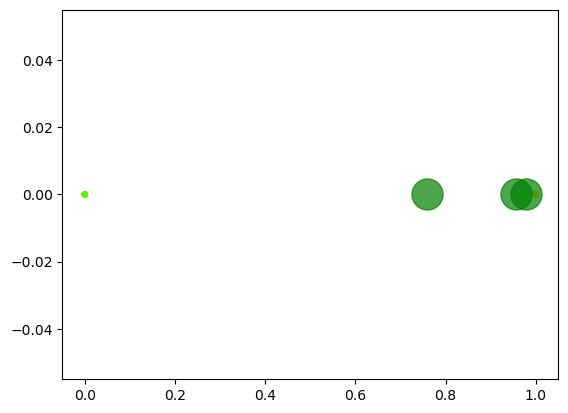

In [123]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=12, cmap='prism')
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='green', s=500, alpha=0.7);

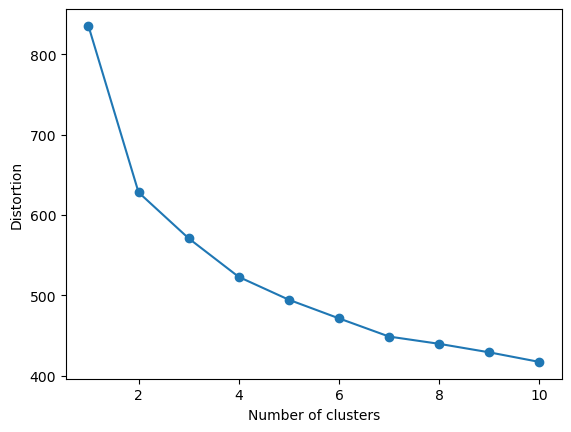

In [124]:
#Για να εκτυπωθεί το Elbow θα κάνουμε χρήση των παρακάτω εντολών 
#Ορίζουμε ένα range τιμών που θα περιέχονται μέσα στην αντίστοιχη γραφική παράσταση
plt.plot(range(1, 11), distortions, marker='o')
#Δίνουμε για τον άξονα x τις τιμές των cluster 
plt.xlabel('Number of clusters')
#Δίνουμε για τον άξονα y τις τιμές τις παραμόρφωσεις 
plt.ylabel('Distortion')
#Δίνουμε την τελική εντολή για να εμφανιστεί η γραφική
plt.show()

In [125]:
#Το ορίζουμε και ζητάμε να εκτυπώσει τις αντίστοιχες ετικέτες σε μορ΄φή πινάκα
kmeans.labels_

array([2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 2, 0, 0,
       2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 2, 0,
       2, 0, 2, 1, 0, 2, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 0, 2, 1, 0, 1, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 1, 2, 0, 2, 2, 2, 0, 2, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 2, 0, 0, 1, 0, 0, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 1, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2,
       2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,

In [126]:
#Στην συνέχεια ορίζουμε να εκτυπώσει το cluster center με τον αντίστοιχο τρόπο
#όπου έχει πάρει είδη τις τιμές του αρχικού κανονικοποιημένου πίνακα για να 
#βγουν τα αντίστοιχα αποτελέσματα
kmeans.cluster_centers_

array([[0.9563, 0.    , 0.9151, 0.4852, 0.9357, 0.5122, 0.9199, 0.4878,
        0.9111, 0.5065, 0.9172, 0.5223, 0.9219, 0.504 , 0.9204, 0.5001,
        0.9015, 0.4902, 0.8869, 0.4924, 0.8902, 0.5321, 0.8814, 0.4823,
        0.8632, 0.4864, 0.8782, 0.4999, 0.8457, 0.4988, 0.8424, 0.4998,
        0.8313, 0.4908],
       [0.9787, 0.    , 0.8456, 0.6895, 0.7628, 0.7997, 0.6578, 0.8975,
        0.4627, 0.8965, 0.2893, 0.8389, 0.2257, 0.7421, 0.1309, 0.6084,
        0.1684, 0.4147, 0.2598, 0.3332, 0.342 , 0.2115, 0.4011, 0.2694,
        0.5426, 0.2329, 0.6398, 0.2946, 0.6521, 0.3904, 0.6577, 0.4349,
        0.633 , 0.559 ],
       [0.7583, 0.    , 0.6654, 0.5134, 0.6082, 0.5334, 0.5988, 0.5391,
        0.6321, 0.5999, 0.6392, 0.5607, 0.5478, 0.5376, 0.5043, 0.563 ,
        0.5727, 0.5447, 0.5271, 0.5432, 0.4568, 0.5775, 0.4858, 0.5353,
        0.5065, 0.5234, 0.6589, 0.4808, 0.4658, 0.5054, 0.4299, 0.5226,
        0.4529, 0.514 ]])

In [127]:
#Ζητάμε να διαβάσει την εντολή 
np.set_printoptions(precision=4,suppress=True)
#Ορίζουμε το KMeans με cluster=7 όπως θεωρούμε με βάση τον αρχικό πίνακα
#glass.data
kmeans = KMeans(n_clusters=3)
#θεωρούμε το kmeans με τις τιμές του κανονικοποιημ΄ένου πίνακα
kmeans.fit(x_minmax)

C:\Users\chaos\anaconda3\envs\LabNavigator\lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=3)

In Elbow method k-means clustering algorithm runs on a given dataset for a range of 
values of k (e.g k=1 to 10), and for each value of k it calculates the sum of squared errors 
(SSE).
Afterwards, it plots a line graph of the SSE for each value of k. If the line graph looks 
like an arm - a red circle in below line graph (like angle), the "elbow" on the arm is the 
value of optimal k (number of cluster). We want to minimize SSE (distortion). SSE tends 
to decrease towards 0 as we increase k (SSE is 0 when k is equal to the number of data 
points in the dataset, because then each data point is its own cluster, and there is no error 
between it and the center of its cluster).
Therefore, the goal is to choose a small value of k that still has a low SSE, and the elbow 
usually represents where we start to have diminishing returns by increasing k.


In [31]:
#Στην συνέχεια θα χρησιμοποιήσουμε το πακέτο yellowbrick έτσι ώστε
#να εκτελέσει μια ποίο διαφορετική μέθοδο 
from yellowbrick.cluster import SilhouetteVisualizer
model=KMeans()
visualizer1= silhouettevisualizer(model)
visualizer1.fit(X)
visualizer1.show()

ModuleNotFoundError: No module named 'yellowbrick'

Silhouette analysis can be used to study the separation distance between the resulting 
clusters. The silhouette plot displays a measure of how close each point in one cluster 
is to points in the neighboring clusters and thus provides a way to assess parameters 
like number of clusters visually. This measure has a range of [-1, 1].

- STEP 6 – Unsupervised learning (Hierarchal Clustering)

In [128]:
#➢ Deploy hierarchical clustering.
#➢ Construct a dendrogram.
#➢ What are your conclusions?

In [129]:
#Χρησιμοποιούμε την αντίστοιχη απόσταση με τις τιμές του κανονικοποιημένου πίνακα
#και με την εξίσωση επίλυσης Ward 
distance=linkage(x_minmax,'ward')

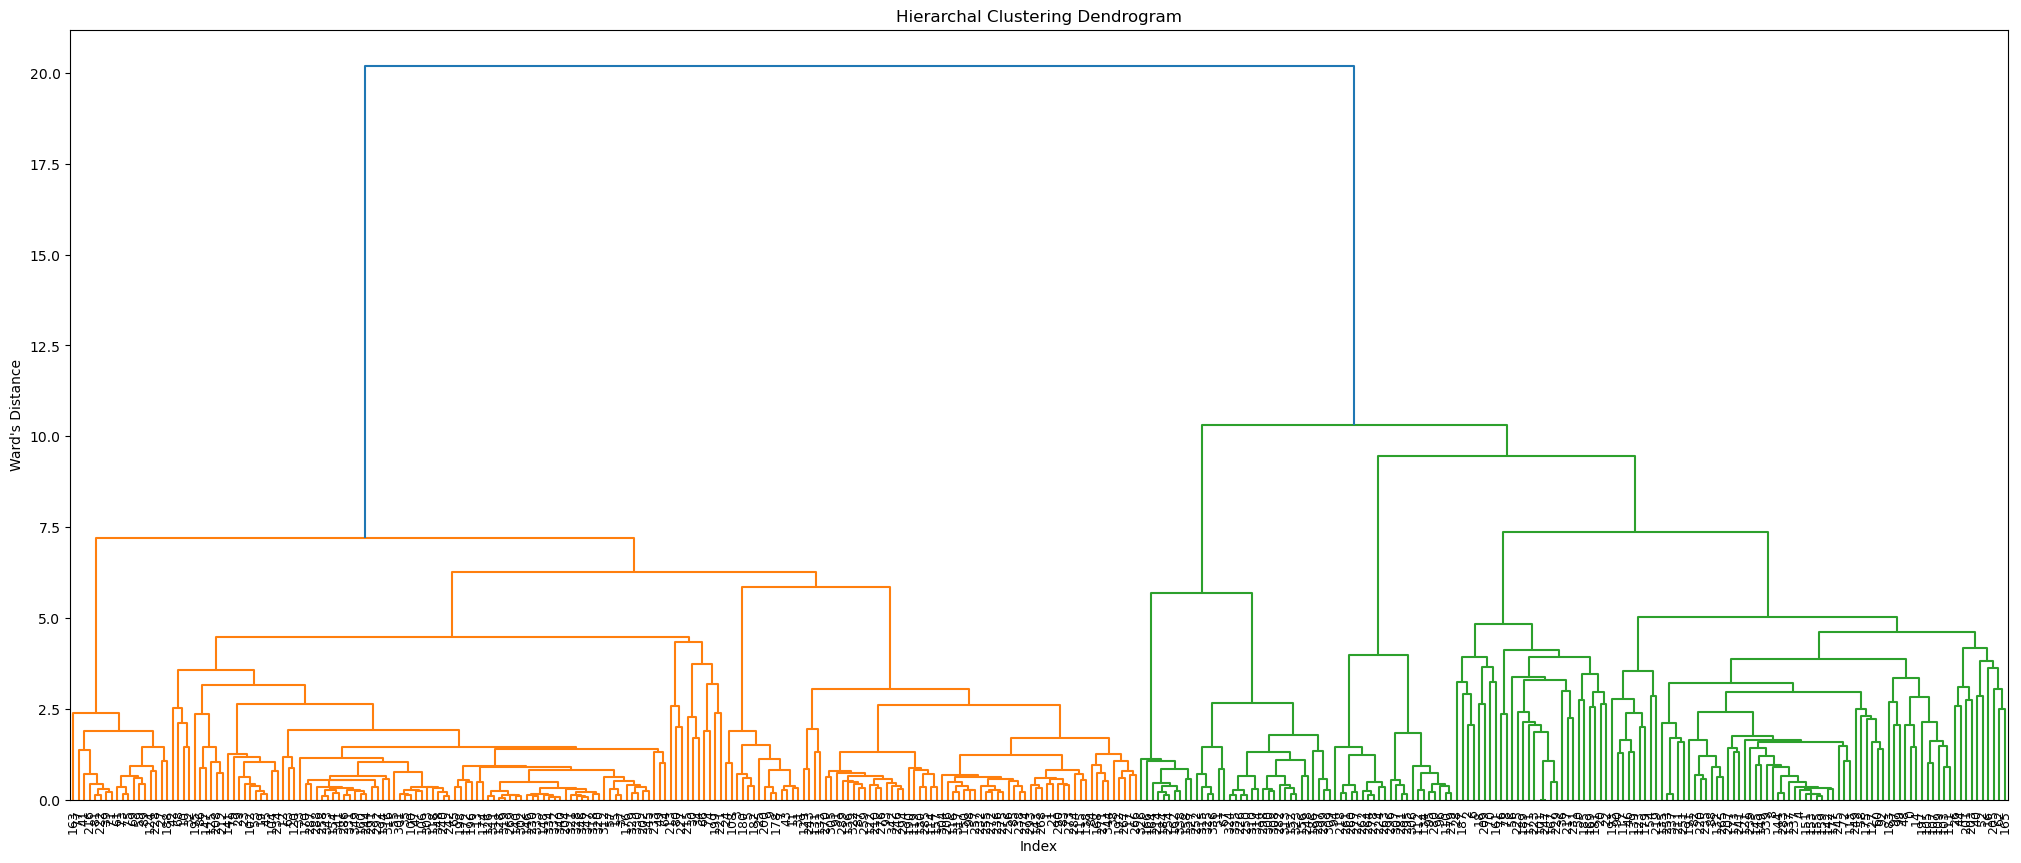

In [130]:
#Ζητάμε το figure να ορίσουμε το αντίστοιχο μεγεθος διαστάσεων 
plt.figure(figsize=(25,10))
#Ορίζουμε τον τίτλο που θα αποτυπωθεί στην αντίστοιχη "γραφική παράσταση"
plt.title("Hierarchal Clustering Dendrogram")
#Ορίζουμε τις τιμ΄΄ες που θα έχει ο άξονας X 
plt.xlabel("Index")
#Ορίζουμε τις τιμές που θα έχει ο άξονας Y 
plt.ylabel("Ward's Distance")
#Τέλος ορίζουμε το δενδόγραμμα όπου και θα αποτυπώνεται το παρακάτω σχ΄΄ημα 
dendrogram(distance,leaf_rotation=90.,leaf_font_size=9.,);

Επειδή στην προηγούμενη επίλυση linkgage είναι με επίλυση ward θα ακολουθήσω ακριβώς την ίδια διαδικασία αλλάζοντας "την σχετική εξίσωση" για να πάρουμε διαφορετικά αποτελέσματα στο δενδρόγραμμα μας έχουμε το εξής 

In [131]:
#Χρησιμοποιούμε την αντίστοιχη απόσταση με τις τιμές του κανονικοποιημένου πίνακα
#και με την εξίσωση επίλυσης με χρ΄ήση του Single 
distance=linkage(x_minmax,'single')

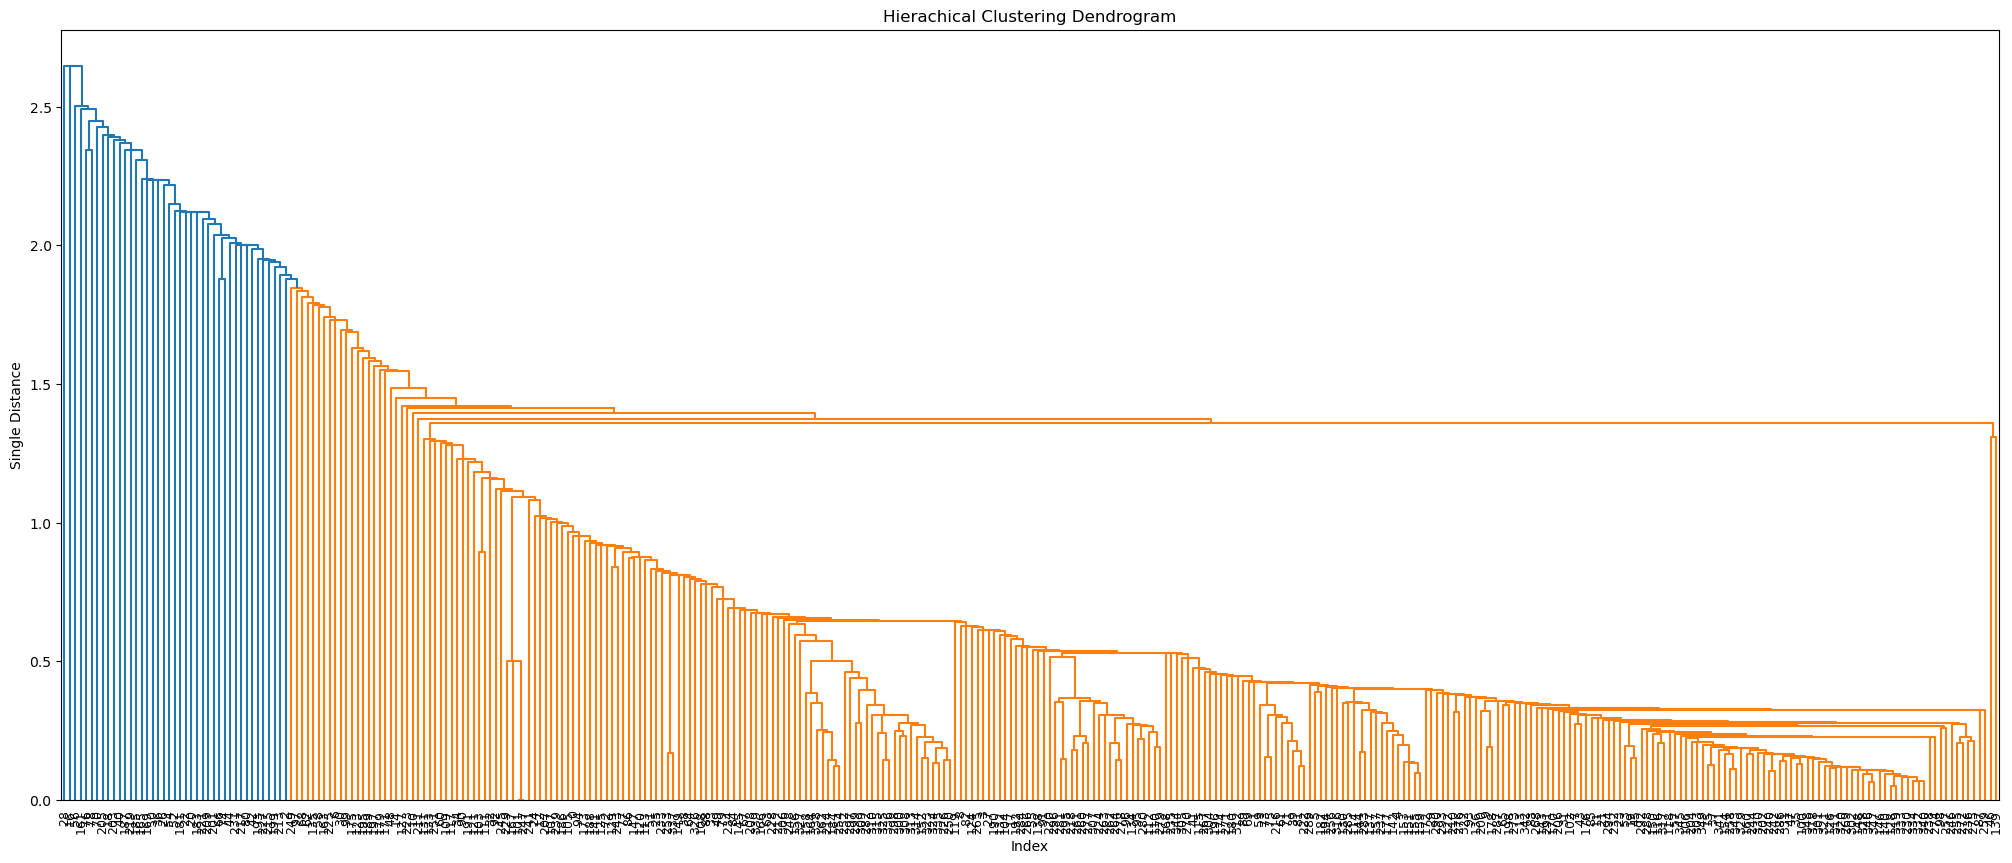

In [132]:
#Ζητάμε το figure να ορίσουμε το αντίστοιχο μέγεθος διαστάσεων
plt.figure(figsize=(25,10))
#ορίζουμε τον τίτλο που θα αποτυπώσει την αντίστοιχη "γραφική παράσταση"
plt.title("Hierachical Clustering Dendrogram")
#Ορίζουμε τις τιμές που θα έχει ο άξονας x
plt.xlabel("Index")
#Ορίζουμε τις τιμές που θα έχει ο άξονας Y 
plt.ylabel("Single Distance")
#και τέλος ορίζουμε το δενδρογραμμά όπου και αποτυπώνεται  παρακάτω 
dendrogram(distance,leaf_rotation=90.,leaf_font_size=9.,);

Παρατηρούμε μια τελείος διαφορετική αποικόνισει σε σύγκριση με την χρήση του ward του οποίο παίρνει διαφορετικές διαστάσεις μεταξύ των "εξισώσεων" φαίνεται ότι αποικονίζει μια ποίο smooth μεταβολή

In [133]:
#Χρησιμοποιούμε την αντίστοιχη απόσταση με τις τιμές του κανονικοποιημένου πίνακα
#και με την εξίσωση επίλυσης με χρ΄ήση του Complete 
distance=linkage(x_minmax,'complete')

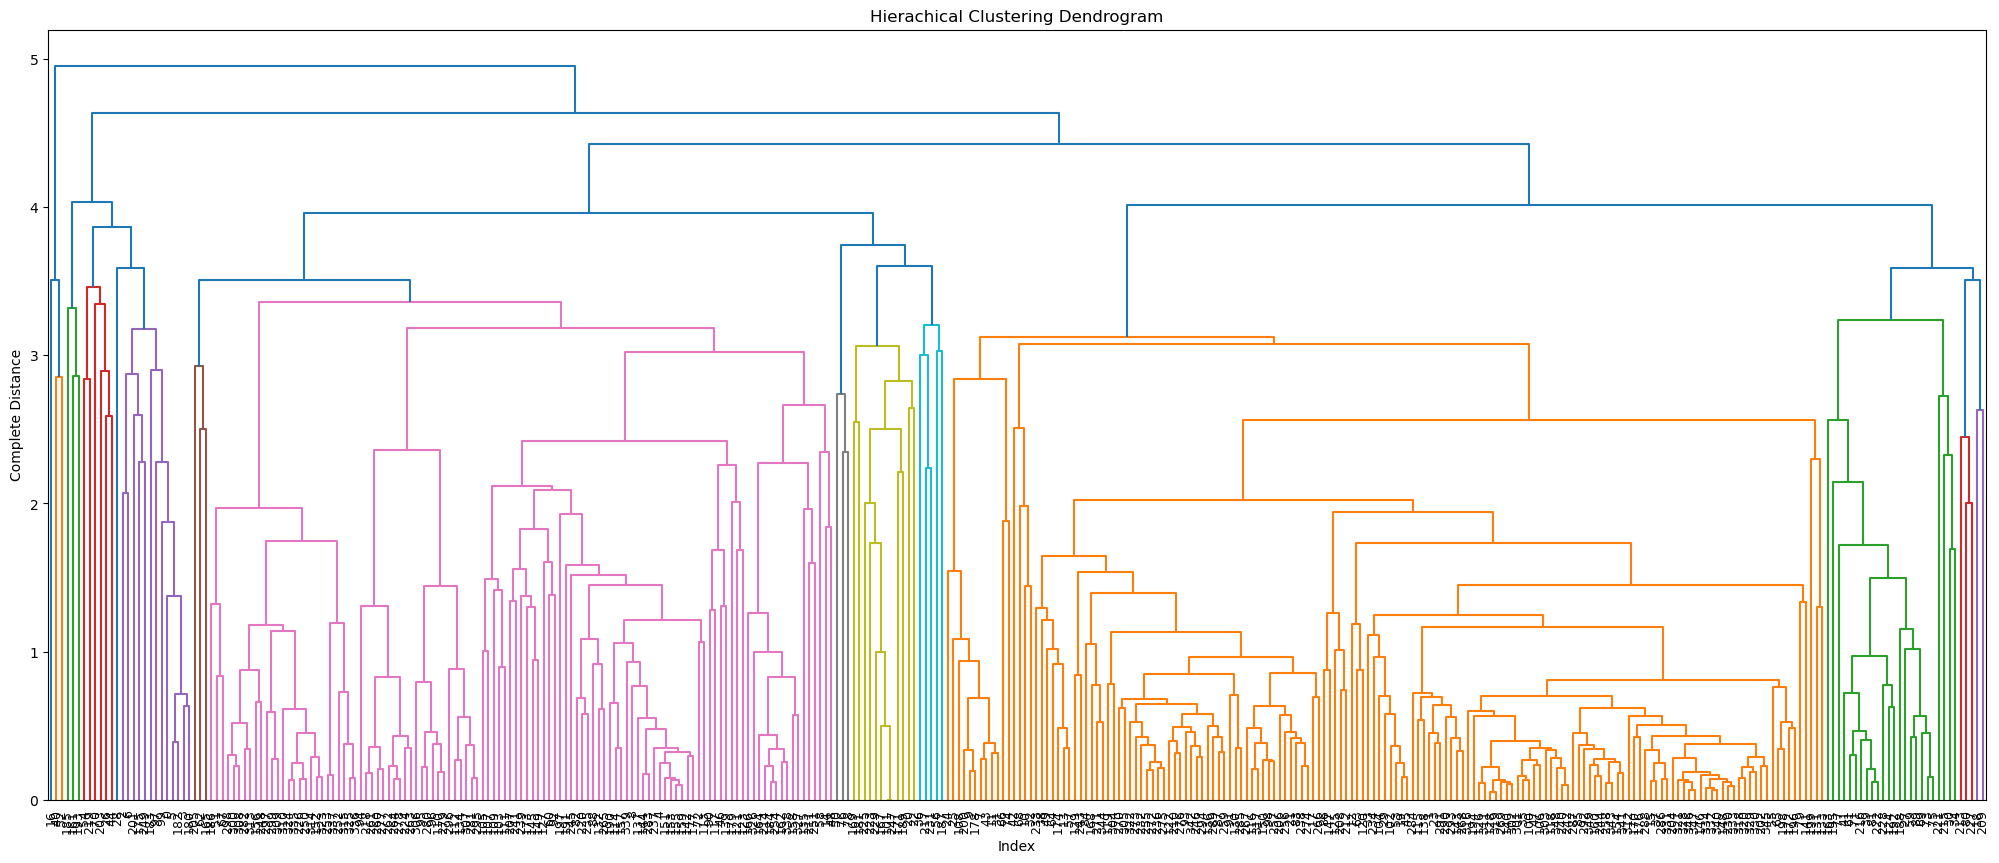

In [134]:
#Ζητάμε το figure να ορίσουμε το αντίστοιχο μέγεθος διαστάσεων
plt.figure(figsize=(25,10))
#ορίζουμε τον τίτλο που θα αποτυπώσει την αντίστοιχη "γραφική παράσταση"
plt.title("Hierachical Clustering Dendrogram")
#Ορίζουμε τις τιμές που θα έχει ο άξονας x
plt.xlabel("Index")
#Ορίζουμε τις τιμές που θα έχει ο άξονας Y 
plt.ylabel("Complete Distance")
#και τέλος ορίζουμε το δενδρογραμμά όπου και αποτυπώνεται  παρακάτω 
dendrogram(distance,leaf_rotation=90.,leaf_font_size=9.,);

Παρατηρούμε ότι η χρήση του Complete παίρνει ένα μεγαλύτερο εύρος τιμών και φαίνονται ποίο διαφορετικά από τα άλλα δύο γραφήματα που μόλις είδαμε , με ποίο πολλές χρήσεις τιμών και χρωμάτων . Τέλος θα κάνουμε την χρήση του average για να συγκρίνουμε την διαφορά μεταξύ των δενδρογραμμάτων.

In [135]:
#Χρησιμοποιούμε την αντίστοιχη απόσταση με τις τιμές του κανονικοποιημένου πίνακα
#και με την εξίσωση επίλυσης με χρ΄ήση του Αverage 
distance=linkage(x_minmax,'average')

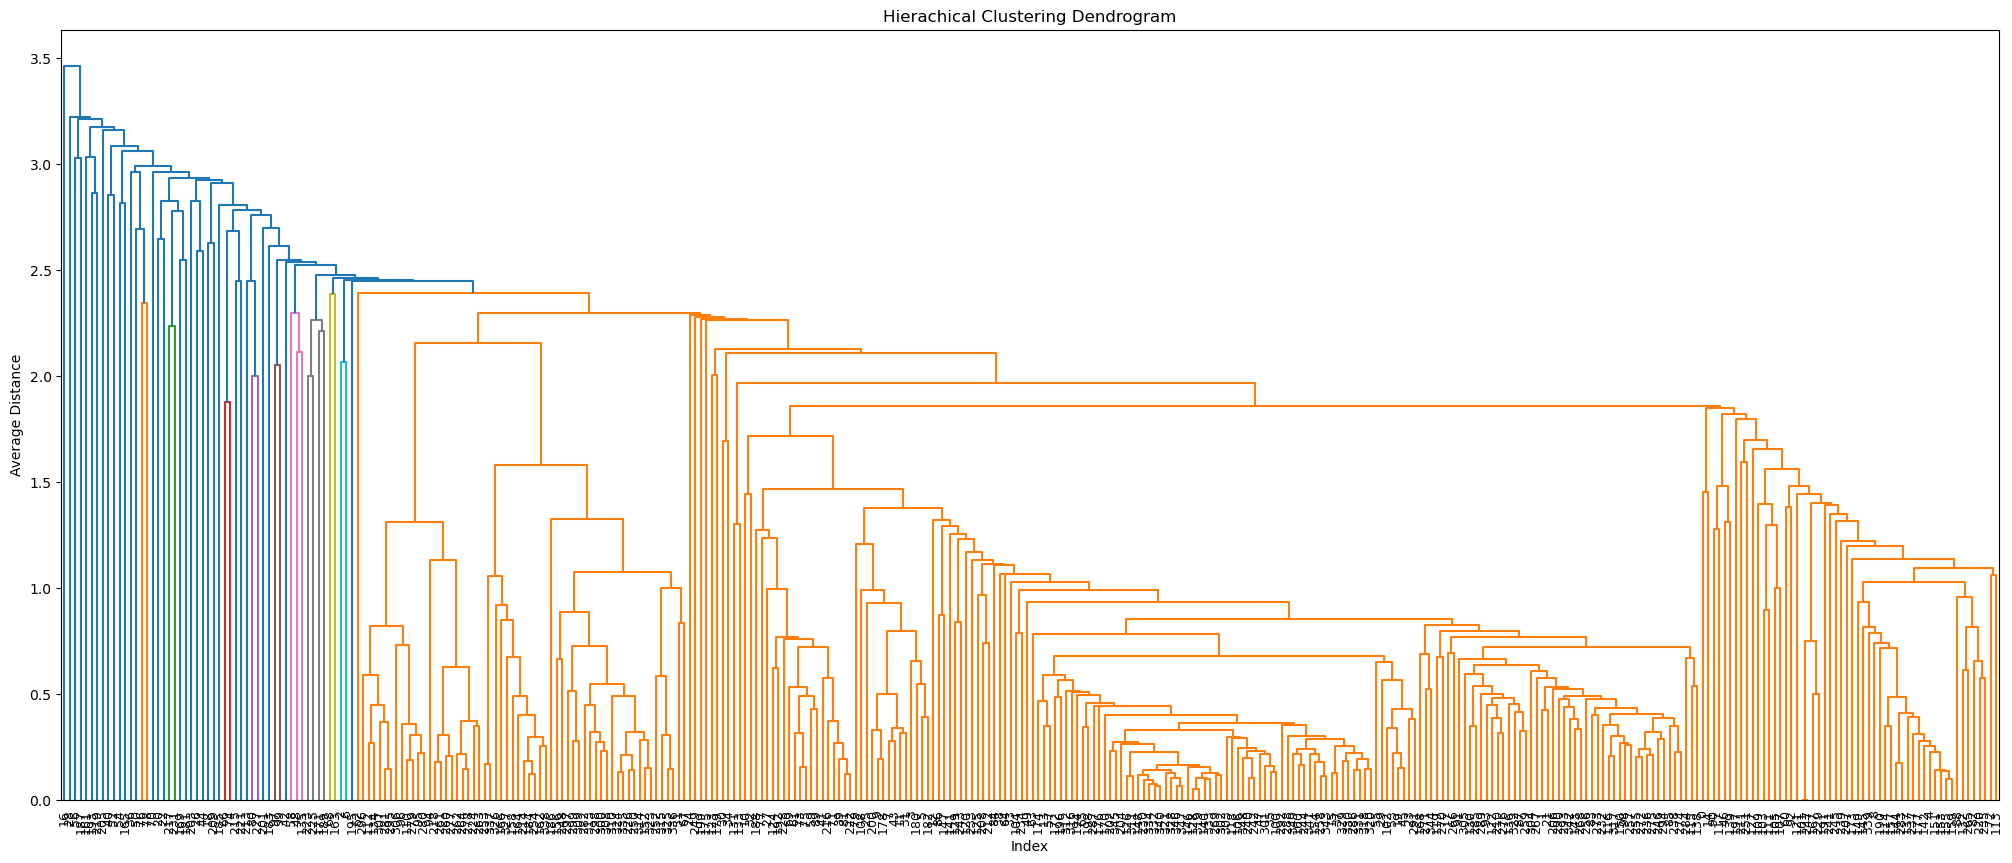

In [136]:
#Ζητάμε το figure να ορίσουμε το αντίστοιχο μέγεθος διαστάσεων
plt.figure(figsize=(25,10))
#ορίζουμε τον τίτλο που θα αποτυπώσει την αντίστοιχη "γραφική παράσταση"
plt.title("Hierachical Clustering Dendrogram")
#Ορίζουμε τις τιμές που θα έχει ο άξονας x
plt.xlabel("Index")
#Ορίζουμε τις τιμές που θα έχει ο άξονας Y 
plt.ylabel("Average Distance")
#και τέλος ορίζουμε το δενδρογραμμά όπου και αποτυπώνεται  παρακάτω 
dendrogram(distance,leaf_rotation=90.,leaf_font_size=9.,);

Παρατηρούμε ότι στην αποικόνισει του Average το σχήμα φαίνεται να είναι σχετικά κοντά με το σχήμα του Single όσο αναφορα το smoothenes αλλά και αυτό ταυτόχρονα με την σειρά του περιβάλλεται από ένα ποσό αρκετών τιμών με διαφορετικών χρωμάτων αντίστοιχα.

- STEP 7 – Naïve Bayes

In [137]:
#➢ Implement a Naïve Bayes model.
#➢ Evaluate the performance of the model by comparing the predicted against the actual results. 
#➢ What are your conclusions?

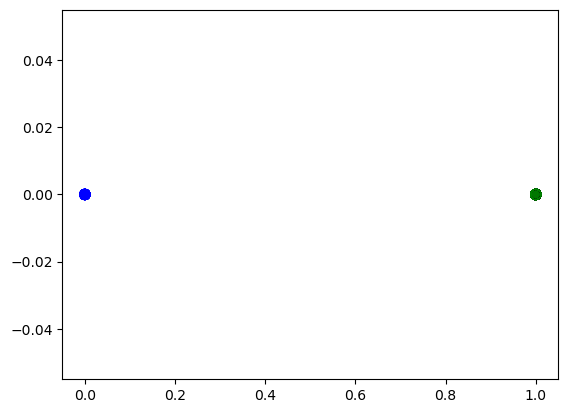

In [138]:
#➢ Implement a Naïve Bayes model.
#Ορίζουμε για το μοντέλο του Naïve Bayes
model = GaussianNB()
model.fit(X,Y);
#Ορίζουμε τις μεταβλητές
rng = np.random.RandomState(0)
ynew = model.predict(X)
#Ζητάμε να εκτυπωθεί 
plt.scatter(X[:, 0], X[:, 1], c=Y, s=50, cmap='RdBu')
lim = plt.axis()
plt.scatter(X[:, 0], X[:, 1], c=ynew, s=20, cmap='RdBu', alpha=0.1)
plt.axis(lim);
#Παρατηρούμε το αποτέλεσμα στον παρακάτω διάγραμμα 

The algorithm is used for classification problems of 2 or more classes. It presupposes 
the independence of features, something that is not often found in the real world. 
However, in most cases it gives very good results. The classifier uses the Bayes 
theorem, which says

- STEP 8 – Conclusion

In [139]:
#➢ Compare the performance of the supervised and unsupervised learning methods you have used.
#➢ What are your conclusions? Justify your opinion. 

Conclusions θα βρισκονται στην αναφορά του ward.